In [1]:
import logging
from trails import Trails, lca, get_lcia_method_names, plot_temporal_scores, search_activity
from datapackage import Package
from trails.logging import configure_trails_logging, trails_log_context
from trails import clear_cache
#clear_cache()

configure_trails_logging(file_level=logging.DEBUG)

dp = Package("/Users/romain/GitHub/premise/dev/trails_2026-01-25.zip")
trails = Trails(dp, interpolate_annual=True, debug=True)
#methods = ["IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",]
methods = [
    'IPCC 2021 - climate change: total (excl. biogenic CO2) - global warming potential (GWP100)',
    "IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)"
]

Loaded interpolated matrices from cache: /Users/romain/Library/Application Support/trails/cache/interp_f23064419269a7d18f5a4a7281f97ec7a5b9e89ce57e4d4359270f975b6e4993


In [2]:
trails.import_excel_inventory("lci-pass_cars.xlsx")

12:05:11+0100 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.
Extracted 1 worksheets in 0.01 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 14 strategies in 0.00 seconds


/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/bw2io/importers/excel.py:35: UserWarning: Invalid first cell (A1) in worksheet biomass
  warnings.warn("Invalid first cell (A1) in worksheet {}".format(sheet))
/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/bw2io/importers/excel.py:35: UserWarning: Invalid first cell (A1) in worksheet daccs
  warnings.warn("Invalid first cell (A1) in worksheet {}".format(sheet))


Imported Excel inventory: new_activities=2 matched_existing_activities=0 new_flows=0 matched_existing_flows=38 unlinked=0 replaced_A=rows replaced_B=rows
New activities created from import:
+-------+---------------------------------------------+---------------------------+-----------+----------+
| index |                     name                    |     reference product     |    unit   | location |
+-------+---------------------------------------------+---------------------------+-----------+----------+
| 39209 |      transport, passenger, car, diesel      | transport, passenger, car | kilometer |   RER    |
| 39210 | transport, passenger, car, battery electric | transport, passenger, car | kilometer |   RER    |
+-------+---------------------------------------------+---------------------------+-----------+----------+


{'production': 2,
 'technosphere': 17,
 'biosphere': 38,
 'new_activities': 2,
 'new_flows': 0,
 'matched_existing_activities': 0,
 'matched_existing_flows': 38,
 'unlinked': 0,
 'replaced_A': 'rows',
 'replaced_B': 'rows',
 'scenario_indices': [35, 15, 75, 95, 55, 0]}

In [3]:
from trails.plotting import plot_temporal_graph

ref_year = 2050
idx=39210
#idx=1219

trails.temporal_routing(
  start_year=ref_year,
  start_act_idx=idx,
  amount=1,
  max_depth=3,
  show_progress=True,
  attribute_to_roots=True,
)

Temporal routing: 8593node [00:02, 3609.21node/s]


In [4]:
trails.lca(
    methods=methods,
    show_progress=True,
    compute_score=True,
    store_inventory=True,
)

Temporal LCA: solve years: 100%|██████████████| 57/57 [03:51<00:00,  4.07s/year]


In [5]:
trails.static_lca(
    year=ref_year,
    act_idx=idx,
    methods=methods,
    debug=True
)
static_score = trails.static_score

In [6]:
from trails.plotting import plot_temporal_scores
figs = plot_temporal_scores(
    stacked=False,
    legend_top_n=7,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2000, 2100),
    reference_year=ref_year,
    show_cumulative_axis=True,
    static_score=static_score,
    static_score_dash= "dot",
    static_score_color= "red",
)

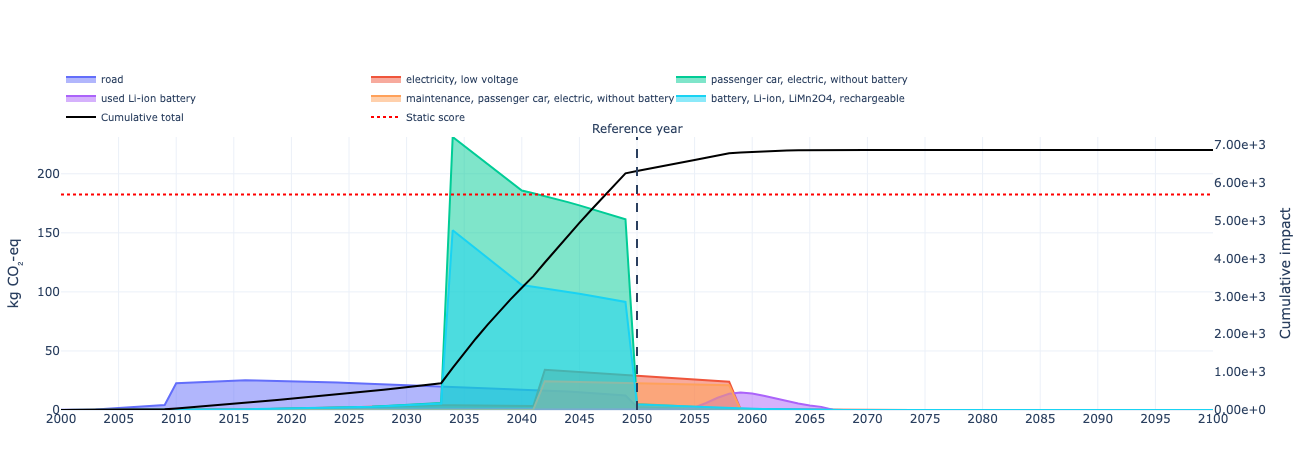

In [7]:
figs[0]

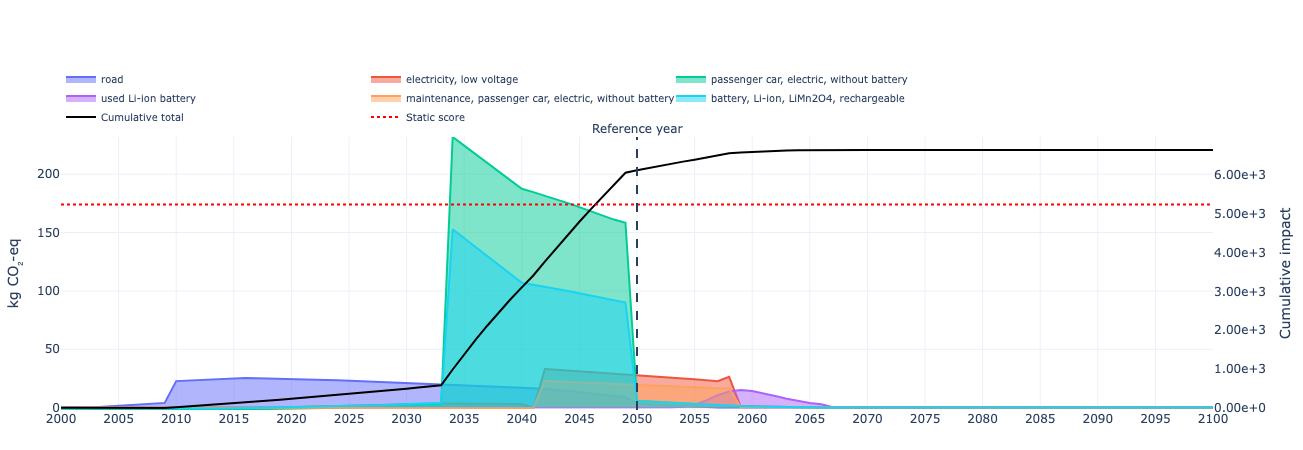

In [8]:
figs[1]

In [9]:
from trails.fair_rf import run_fair_delta_rf

rf = run_fair_delta_rf(
    trails,
    scenario="high-extension",
    scale_target_fraction=0.1,
)

/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



FAIR emissions delta check failed: CO2 FFI: max_abs=6.871e-03 kg/yr max_rel=3.433e-03; CO: max_abs=6.851e-05 kg/yr max_rel=1.137e-02; CH4: max_abs=5.652e-05 kg/yr max_rel=2.795e-01; N2O: max_abs=1.707e-06 kg/yr max_rel=6.197e-03


FaIR per-species:  14%|██▌               | 2/14 [00:23<02:22, 11.84s/specie, CO]/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning:

All-NaN slice encountered

FaIR per-species:  71%|███████████▍    | 10/14 [02:11<00:50, 12.53s/specie, VOC]/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning:

All-NaN slice encountered

FaIR per-species:  86%|█████████████▋  | 12/14 [02:34<00:24, 12.20s/specie, NOx]/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning:

All-NaN slice encountered

FaIR per-species: 100%|████████████████| 14/14 [02:58<00:00, 12.76s/specie, N2O]


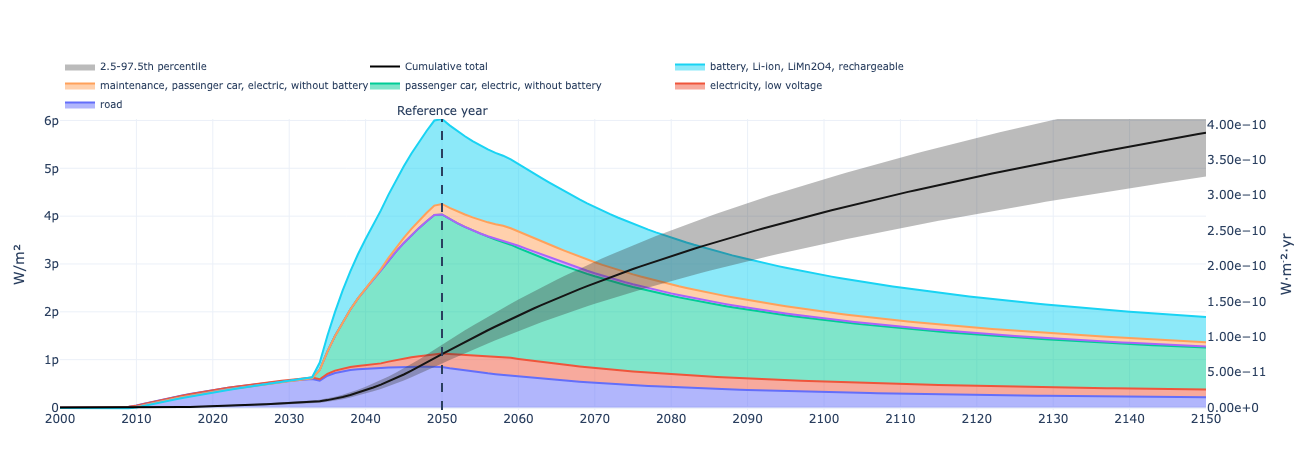

In [10]:
from trails.plotting import plot_rf

fig = plot_rf(
    trails=trails,
    reference_year=2050,
    #by="flow",
    year_range=(2000, 2150),
    year_tick=10,
)
fig.show()

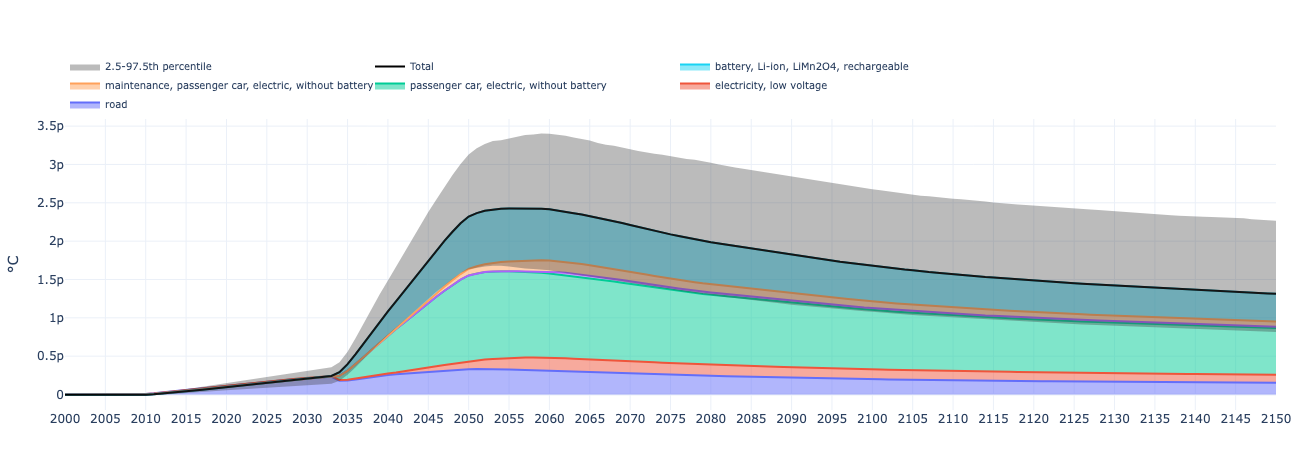

In [11]:
from trails import plot_temp

plot_temp(
    trails,
    by="root activity",
    title="Temperature change by root activity",
    method_label="°C",
    year_range=(2000, 2150),
)